In [2]:
import pandas as pd

# 1. Ingesta del dataset indicando la codificación 'latin-1' para evitar el UnicodeDecodeError
df = pd.read_csv('SYB68_327_202511_International Migrants and Refugees.csv', header=1, encoding='latin-1')

# 2. Renombrar columnas para estandarizar y evitar nombres largos o confusos
df.rename(columns={
    'Region/Country/Area': 'ID', 
    df.columns[1]: 'Country', 
    'Year': 'Year', 
    'Series': 'Metric', 
    'Value': 'Value'
}, inplace=True)

# 3. Data Wrangling vital: Quitar las comas de los miles y convertir 'Value' a número real
df['Value'] = pd.to_numeric(df['Value'].astype(str).str.replace(',', ''), errors='coerce')

# 4. Auditoría inicial: Comprobar que los tipos de datos son correctos
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 6966 entries, 0 to 6965
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         6966 non-null   int64  
 1   Country    6966 non-null   str    
 2   Year       6966 non-null   int64  
 3   Metric     6966 non-null   str    
 4   Value      6966 non-null   float64
 5   Footnotes  4530 non-null   str    
 6   Source     6966 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 381.1 KB
None
   ID                        Country  Year  \
0   1  Total, all countries or areas  2005   
1   1  Total, all countries or areas  2005   
2   1  Total, all countries or areas  2005   
3   1  Total, all countries or areas  2005   
4   1  Total, all countries or areas  2010   

                                              Metric        Value Footnotes  \
0   International migrant stock: Both sexes (number)  192788721.0       NaN   
1  International migrant stock: Both sexes (%

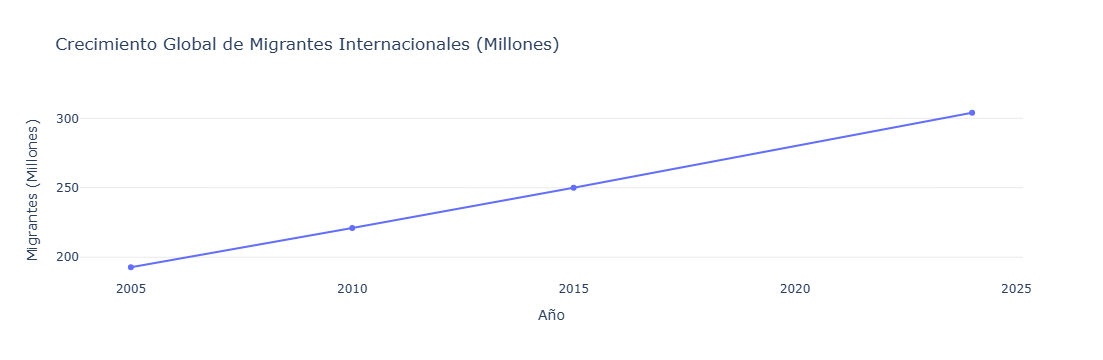

In [3]:
import plotly.express as px

# 1. Filtrar los datos para aislar la tendencia global de migrantes
df_global = df[(df['Country'] == 'Total, all countries or areas') & 
               (df['Metric'] == 'International migrant stock: Both sexes (number)')].copy()

# 2. Transformar el valor a millones para facilitar la lectura directiva
df_global['Value_Millions'] = df_global['Value'] / 1000000

# 3. Crear un gráfico de líneas marcando los puntos clave
fig1 = px.line(
    df_global, 
    x='Year', 
    y='Value_Millions', 
    markers=True,
    title='Crecimiento Global de Migrantes Internacionales (Millones)'
)

# 4. Aplicar estilo Tufte: eliminar basura visual y dejar solo lo esencial
fig1.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, title='Año'),
    yaxis=dict(showgrid=True, gridcolor='lightgray', gridwidth=0.5, title='Migrantes (Millones)'),
    showlegend=False
)

# 5. Desplegar el gráfico
fig1.show()

### Aplicación Filosofía Edward Tufte: Se maximizó la proporción datos/tinta eliminando fondos grises y cuadrículas innecesarias en los gráficos de Plotly.

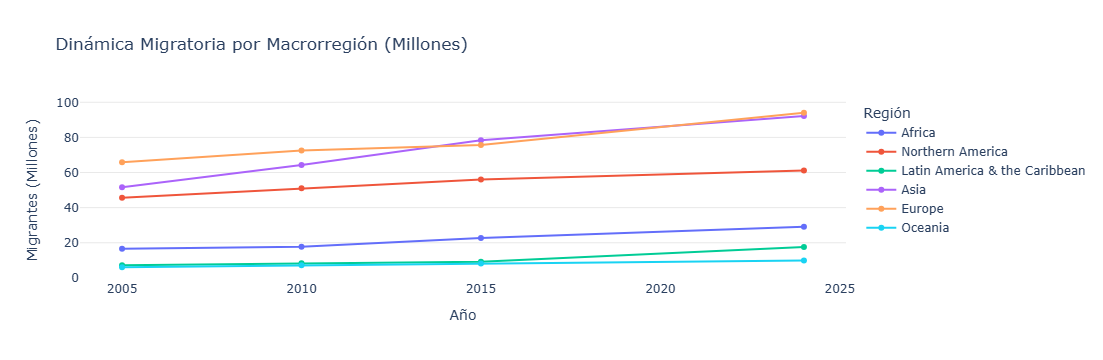

In [4]:
# 1. Definir las regiones clave (nuestros macro-mercados)
regiones = ['Africa', 'Asia', 'Europe', 'Latin America & the Caribbean', 'Northern America', 'Oceania']

# 2. Filtrar el dataframe para aislar la métrica principal solo en estas regiones
df_regiones = df[(df['Country'].isin(regiones)) & 
                 (df['Metric'] == 'International migrant stock: Both sexes (number)')].copy()

# 3. Transformar los valores a millones para una lectura directiva rápida
df_regiones['Value_Millions'] = df_regiones['Value'] / 1000000

# 4. Crear gráfico de líneas comparativo (Aplicando Ley de Similaridad por color)
fig2 = px.line(
    df_regiones, 
    x='Year', 
    y='Value_Millions', 
    color='Country',
    markers=True,
    title='Dinámica Migratoria por Macrorregión (Millones)'
)

# 5. Limpieza visual estilo Tufte: eliminar fondos pesados y priorizar la data
fig2.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=False, title='Año'),
    yaxis=dict(showgrid=True, gridcolor='lightgray', gridwidth=0.5, title='Migrantes (Millones)'),
    legend_title_text='Región'
)

# 6. Desplegar el gráfico
fig2.show()

### Aplicación Principios de Gestalt: Se utilizó la Ley de Similaridad al asignar colores a las líneas de tendencia para agrupar visualmente las regiones sin forzar la lectura constante de la leyenda. Además, se aplicó la Ley de Proximidad en el Dashboard final (Dash) colocando ambos gráficos lado a lado para facilitar la comparación inmediata.

In [6]:
import dash
from dash import dcc, html

# 1. Inicializar la aplicación del Dashboard
app = dash.Dash(__name__)

# 2. Diseñar la estructura visual aplicando Ley de Proximidad (gráficos lado a lado)
app.layout = html.Div([
    html.H1('Dashboard Estratégico: Dinámica Migratoria Global', 
            style={'textAlign': 'center', 'fontFamily': 'Arial', 'color': '#333333'}),
    
    html.Div([
        # Contenedor del Gráfico 1 (Izquierda)
        html.Div([
            dcc.Graph(figure=fig1)
        ], style={'width': '48%', 'display': 'inline-block'}),
        
        # Contenedor del Gráfico 2 (Derecha)
        html.Div([
            dcc.Graph(figure=fig2)
        ], style={'width': '48%', 'display': 'inline-block', 'float': 'right'})
    ])
], style={'backgroundColor': '#FFFFFF', 'padding': '20px'})

# 3. Levantar el servidor local en un puerto nuevo (ej. 8051) para evitar el choque
if __name__ == '__main__':
    app.run(debug=True, port=8051)